# 04 · Corpus y dataset — de 396 grafos a la muestra que se puede medir

Antes de cualquier métrica hay que fijar **sobre qué población se mide**. Este notebook
construye esa población desde los archivos, sin números citados de memoria, y documenta
los problemas de calidad del dataset de origen que hay que declarar en el paper.

Tres preguntas:

1. ¿Cuántos grafos del ground truth son **medibles**?
2. ¿Cuántos videos procesó cada pipeline y cuántos **comparten**?
3. ¿Qué problemas de calidad tiene el catálogo de videos?

In [1]:
import csv
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

GT_DIR = Path("../data/cloudscape_gt")
RUNS   = Path("../reports/runs")
pd.set_option("display.width", 200)

STD  = RUNS / "2026-08-20_standard_v6corrected_370v/results.csv"
PARS = RUNS / "2026-08-21_parsimonious_v9/results.csv"

gt = {}
for f in sorted(GT_DIR.glob("*.graphml")):
    G = nx.read_graphml(f)
    usable = str(G.graph.get("graph_usable", "True")).strip().lower() not in ("false", "0")
    gt[f.stem] = {"nombre": G.graph.get("name", ""), "usable": usable,
                  "categorias": G.graph.get("categories", ""),
                  "nodos": G.number_of_nodes(), "aristas": G.number_of_edges()}

GT = pd.DataFrame.from_dict(gt, orient="index").rename_axis("video_id")
print(f"grafos en el ground truth : {len(GT)}")
print(f"  graph_usable = True     : {int(GT.usable.sum())}")
print(f"  graph_usable = False    : {int((~GT.usable).sum())}")

grafos en el ground truth : 396
  graph_usable = True     : 340
  graph_usable = False    : 56


## 1 · Los 56 grafos que Cloudscape marca como inservibles

`graph_usable` es una anotación **del propio Cloudscape**, no un criterio nuestro: marca
los grafos que sus anotadores consideraron no utilizables. Incluirlos en las medias
publicadas infla o desinfla el resultado sin que nadie lo vea, así que se excluyen de toda
métrica y se reportan aparte.

56 grafos inservibles



,nombre,nodos,aristas
video_id,,,
1ZLiRT0C2Yo,T-Mobile: Standardized Container-Based Archite...,6,0
1kWxymroGeE,OutSystems: Decomposing a Data Monolith for Sc...,5,4
1tGmQd0yOzE,Whirlpool: Resilient SAP on AWS,8,12
62E9ggjGS8I,DISH Network: Building a Self-Service Portal t...,7,9
6sY0AunanlM,NGINX: Deploy and Scale Applications with Ease...,4,0
8TExnSvZqt0,AxiomSL's RegCloud®️: Secure & Scalable Risk &...,11,0
99nNHsbwBpg,SkyScanner: Building HighlyAvailable MultiRegi...,2,0
9JwZKseE9lc,This is My Architecture: Security Customer Spo...,2,1
9LhiUsg3knw,Musixmatch: How Content is Generated by Users ...,13,8



grafos del GT con CERO aristas: 21  (de los cuales inservibles: 21)
Un grafo sin aristas no puede puntuar Edge F1: el denominador es 0.


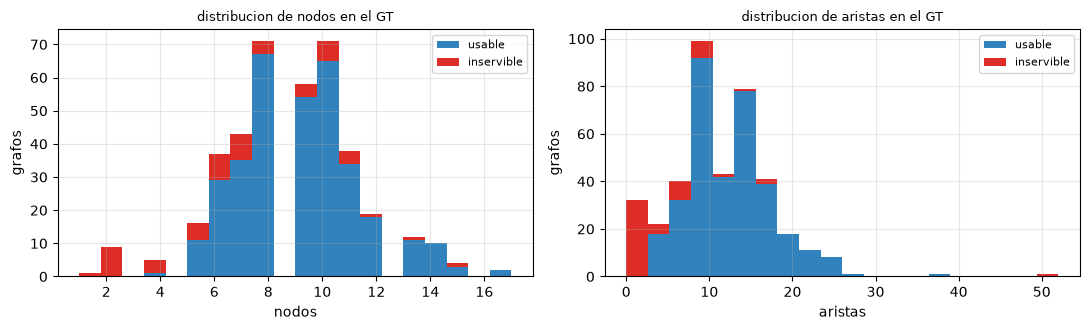


GT usable — nodos: mediana 9, media 9.12
GT usable — aristas: mediana 12, media 12.31


In [2]:
inservibles = GT[~GT.usable]
print(f"{len(inservibles)} grafos inservibles\n")
display(inservibles[["nombre", "nodos", "aristas"]].head(12))

sin_aristas = GT[GT.aristas == 0]
print(f"\ngrafos del GT con CERO aristas: {len(sin_aristas)}  "
      f"(de los cuales inservibles: {int((~sin_aristas.usable).sum())})")
print("Un grafo sin aristas no puede puntuar Edge F1: el denominador es 0.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col in zip(axes, ["nodos", "aristas"]):
    ax.hist([GT[GT.usable][col], GT[~GT.usable][col]], bins=20, stacked=True,
            label=["usable", "inservible"], color=["#3182bd", "#de2d26"])
    ax.set_xlabel(col); ax.set_ylabel("grafos"); ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax.set_title(f"distribucion de {col} en el GT", fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nGT usable — nodos: mediana {GT[GT.usable].nodos.median():.0f}, "
      f"media {GT[GT.usable].nodos.mean():.2f}")
print(f"GT usable — aristas: mediana {GT[GT.usable].aristas.median():.0f}, "
      f"media {GT[GT.usable].aristas.mean():.2f}")

## 2 · Emparejamiento entre los dos pipelines

Un pipeline solo puede evaluarse en los videos que **procesó** y que **tienen ground
truth**. Y la comparación entre los dos exige la intersección de ambos.

In [3]:
S = pd.read_csv(STD)
P = pd.read_csv(PARS)

print(f"Standard      : {len(S)} videos procesados · {int((S.graph_usable == True).sum())} con GT usable")
print(f"Parsimonious  : {len(P)} videos procesados · {int((P.graph_usable == True).sum())} con GT usable")

m = S.merge(P, on="video_id", suffixes=("_s", "_p"))
pareados = m[(m.graph_usable_s == True) & (m.graph_usable_p == True)]

print(f"\nvideos en comun                       : {len(m)}")
print(f"pareados Y usables en los dos (n=)     : {len(pareados)}   <- muestra de la comparacion pareada")
print(f"Parsimonious usable (su propia media)  : {int((P.graph_usable == True).sum())}")

resumen_pob = pd.DataFrame([
    {"poblacion": "GT total",                       "n": len(GT)},
    {"poblacion": "GT usable",                      "n": int(GT.usable.sum())},
    {"poblacion": "Standard procesados",            "n": len(S)},
    {"poblacion": "Parsimonious procesados",        "n": len(P)},
    {"poblacion": "comunes a los dos",              "n": len(m)},
    {"poblacion": "PAREADOS usables (comparacion)", "n": len(pareados)},
]).set_index("poblacion")
display(resumen_pob)

Standard      : 370 videos procesados · 321 con GT usable
Parsimonious  : 385 videos procesados · 336 con GT usable

videos en comun                       : 370
pareados Y usables en los dos (n=)     : 321   <- muestra de la comparacion pareada
Parsimonious usable (su propia media)  : 336


,n
poblacion,
GT total,396
GT usable,340
Standard procesados,370
Parsimonious procesados,385
comunes a los dos,370
PAREADOS usables (comparacion),321


**Las dos poblaciones que aparecen en el paper, y no hay que confundirlas:**

- **n = 336** — los videos usables de Parsimonious. Es el denominador de *su* media suelta.
- **n = 321** — los que los **dos** pipelines procesaron con GT usable. Es el único
  denominador válido para la **comparación pareada**, porque controla por dificultad del
  video en vez de comparar dos promedios sobre corpus distintos.

## 3 · Calidad del catálogo de videos

`videos.csv` es el catálogo scrapeado de la lista de reproducción. Tiene dos defectos que
conviene reportar como hallazgo sobre el dataset de origen.

In [4]:
vids = list(csv.DictReader(open("../videos.csv", encoding="utf-8")))
con_id = [r for r in vids if (r.get("video_id") or "").strip()]
sin_id = [r for r in vids if not (r.get("video_id") or "").strip()]

print(f"filas en videos.csv     : {len(vids)}")
print(f"  con video_id          : {len(con_id)}")
print(f"  SIN video_id (vacio)  : {len(sin_id)}")


def norm(s: str) -> str:
    """Titulo comparable: solo alfanumericos en minuscula."""
    return re.sub(r"[^a-z0-9]", "", (s or "").lower())


gt_por_titulo = {norm(v["nombre"]): k for k, v in gt.items() if v["nombre"]}

desalineadas = [
    {"titulo": r["title"][:56], "id_en_csv": r["video_id"].strip(),
     "id_en_GT": gt_por_titulo[norm(r["title"])]}
    for r in con_id
    if norm(r.get("title")) in gt_por_titulo
    and gt_por_titulo[norm(r.get("title"))] != r["video_id"].strip()
]
D = pd.DataFrame(desalineadas)
print(f"\nfilas cuyo TITULO coincide con un episodio del GT pero cuyo video_id NO: {len(D)}")
display(D.head(15))

ids_csv = {r["video_id"].strip() for r in con_id}
print(f"\nde esos IDs correctos, {sum(1 for d in desalineadas if d['id_en_GT'] in ids_csv)} "
      f"ya estaban en videos.csv en otra fila (a menudo sin titulo).")

filas en videos.csv     : 570
  con video_id          : 504
  SIN video_id (vacio)  : 66

filas cuyo TITULO coincide con un episodio del GT pero cuyo video_id NO: 33


,titulo,id_en_csv,id_en_GT
0,Seera Group: Transforming Online Travel Bookin...,7wBOFcP1HwA,a6kqyqTNJM4
1,AMPOS: Managing Systems Across AWS Global Regi...,8FKNVfAU6SI,YT21s0_ZJVQ
2,Delhivery: Building a Supply Chain Technology ...,he5I6ByoaB4,WZ4YL4Z177Q
3,Tata Global Beverages: How a Global CPG Enterp...,0NOER-Lle-0,wzGYJ6BB0iY
4,ZS Associates: Intelligent Process Automation ...,JG5p-i8Cr2E,mq3XuoN0rUM
5,Veracode: Eliminating Application Security Bug...,CyMKbK0grl8,Wk9mCHyjtBU
6,AWS Solutions: Media Analysis,VQ9d3bO4jgg,uQFtb0iMC_s
7,Ashok Leyland: Running Telematics at Scale,8uoQOGh8iGQ,a59halVklMI
8,Enel: Management and Analysis of Meter's Data ...,dVehfigaGuU,illMCyp4O9A
9,DAZN: Key Moments in Sport on Live Streaming V...,7AMRfNKwuYo,dWCQw_KvlYQ



de esos IDs correctos, 32 ya estaban en videos.csv en otra fila (a menudo sin titulo).


### Lectura, y una corrección

El título nombra un episodio real de la serie pero el `video_id` apunta a **otro video**.
Es un defecto del catálogo de origen, no del pipeline, y explica parte de los huérfanos:
el ID correcto suele estar presente en otra fila, sin título.

> **Corrección respecto del `ara/`.** §3.1 del `ara` reporta *"14 filas con el `video_id`
> equivocado"*. Recalculado acá sobre los archivos vigentes da un número distinto (ver
> celda anterior). La cifra que vale es la que produce este notebook; la del `ara` es
> anterior a la última resincronización del corpus y **no debe citarse**.

Los huérfanos catalogados aparte están en `data/gt_orphans_uncatalogued.csv`.

In [5]:
orf = pd.read_csv("../data/gt_orphans_uncatalogued.csv")
print(f"huerfanos del GT sin entrada limpia en el catalogo: {len(orf)}")
display(orf.head(8))

OUT = Path("../reports/corpus.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/04_corpus_y_dataset.ipynb",
    "gt_total": len(GT), "gt_usable": int(GT.usable.sum()),
    "gt_inservible": int((~GT.usable).sum()),
    "gt_cero_aristas": int((GT.aristas == 0).sum()),
    "standard_procesados": len(S), "parsimonious_procesados": len(P),
    "comunes": len(m), "pareados_usables": len(pareados),
    "parsimonious_usables": int((P.graph_usable == True).sum()),
    "videos_csv_filas": len(vids), "videos_csv_sin_id": len(sin_id),
    "videos_csv_id_desalineado": len(D),
    "gt_huerfanos": len(orf),
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nescrito -> {OUT}")

huerfanos del GT sin entrada limpia en el catalogo: 72


,video_id,gt_title,link
0,1tGmQd0yOzE,Whirlpool: Resilient SAP on AWS,https://www.youtube.com/watch?v=1tGmQd0yOzE
1,4zVB5RbSTCo,Electroneum: Mobile Cryptocurrency Mining!,https://www.youtube.com/watch?v=4zVB5RbSTCo
2,5QbKp0LQaZo,GumGum Verity: Low Latency Contextual Analysis...,https://www.youtube.com/watch?v=5QbKp0LQaZo
3,66h7DrOEF5k,ABEJA: Building a Machine Learning Platform th...,https://www.youtube.com/watch?v=66h7DrOEF5k
4,Bi-1xjXvKgs,tixCraft: Handling Millions of Ticketing Reque...,https://www.youtube.com/watch?v=Bi-1xjXvKgs
5,D_4dsXVqzMs,Met Office: Building an Entirely Serverless Na...,https://www.youtube.com/watch?v=D_4dsXVqzMs
6,DxHO2TWVN8I,Equinix: Massive Data Ingest Analytics with S...,https://www.youtube.com/watch?v=DxHO2TWVN8I
7,H51Ups01ZpU,AT&T: Bringing IoT to the Enterprise,https://www.youtube.com/watch?v=H51Ups01ZpU



escrito -> ../reports/corpus.json


## Para el paper

- La población de evaluación es **n = 321** (pareada) o **n = 336** (Parsimonious sola).
  Declarar cuál se usa en cada tabla.
- **56 de 396** grafos del GT están marcados como inservibles **por Cloudscape** y se
  excluyen de toda media publicada.
- El catálogo de origen tiene filas con `video_id` desalineado del título y filas sin ID:
  es un hallazgo reportable sobre la calidad del dataset, y afecta a cualquiera que use
  esa lista.